# 

# Tarea 1

In [60]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import ElasticNet
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline

## EDA

In [61]:
data = pd.read_csv("exercise_dataset.csv") #Importar dataset

In [62]:
data.head() #Revisar las primeras filas del dataset

,"Activity, Exercise or Sport (1 hour)",130 lb,155 lb,180 lb,205 lb,Calories per kg
0,"Cycling, mountain bike, bmx",502,598,695,791,1.750730
1,"Cycling, <10 mph, leisure bicycling",236,281,327,372,0.823236
2,"Cycling, >20 mph, racing",944,1126,1308,1489,3.294974
3,"Cycling, 10-11.9 mph, light",354,422,490,558,1.234853
4,"Cycling, 12-13.9 mph, moderate",472,563,654,745,1.647825


In [92]:
data.isnull().sum() #Revisar valores nulos, si es que hay

Actividad (1h)    0
~59 kg            0
~70 kg            0
~81 kg            0
~93 kg            0
Cal/Kilo          0
dtype: int64

In [93]:
data.duplicated().sum() #Revisar valores duplicados, si es que hay

np.int64(0)

In [64]:
data.columns

Index(['Activity, Exercise or Sport (1 hour)', '130 lb', '155 lb', '180 lb',
       '205 lb', 'Calories per kg'],
      dtype='object')

Por conveniencia vamos a dejar las columnas con la conversión a KG y la columna 'Activity, Exercise or Sport (1 hour)' como solo Actividad(1h) representando todo

In [65]:
data.columns = ['Actividad (1h)', '~59 kg', '~70 kg', '~81 kg', '~93 kg', 'Cal/Kilo']
data.columns

Index(['Actividad (1h)', '~59 kg', '~70 kg', '~81 kg', '~93 kg', 'Cal/Kilo'], dtype='object')

In [66]:
data.describe() #Descripción del dataset

,~59 kg,~70 kg,~81 kg,~93 kg,Cal/Kilo
count,248.000000,248.000000,248.000000,248.000000,248.000000
mean,389.754032,464.689516,539.685484,614.620968,1.359930
std,194.434028,232.019135,269.430029,306.847470,0.678851
min,89.000000,106.000000,123.000000,140.000000,0.310067
25%,236.000000,281.000000,327.000000,372.000000,0.823236
50%,354.000000,422.000000,490.000000,558.000000,1.234853
75%,472.000000,563.000000,654.000000,745.000000,1.647825
max,1062.000000,1267.000000,1471.000000,1675.000000,3.706591


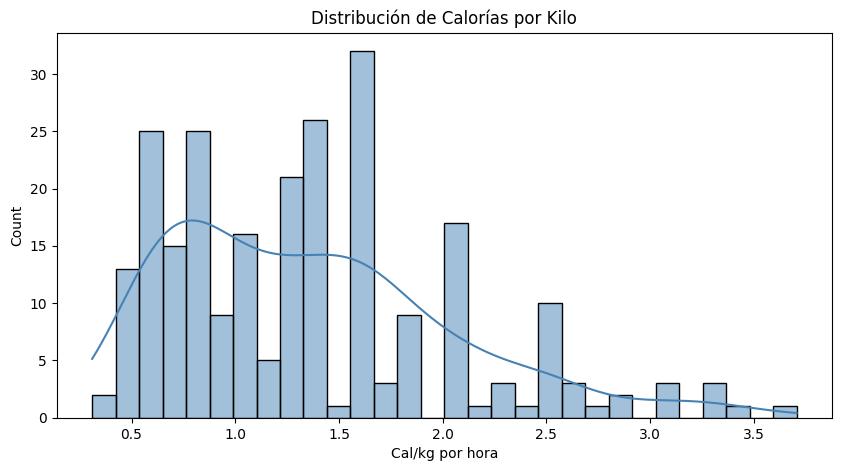

In [67]:
plt.figure(figsize=(10, 5))
sns.histplot(data['Cal/Kilo'], kde=True, bins=30, color='steelblue')
plt.title('Distribución de Calorías por Kilo')
plt.xlabel('Cal/kg por hora')
plt.show()

La distribución nos muestra que el consumo de calorias por kilo en las actividades que el dataset son sumamente bajas, lo cual me hace mucho ruido, y justamente viendo en [Dataset](https://www.kaggle.com/datasets/aadhavvignesh/calories-burned-during-exercise-and-activities?resource=download), se puede ver que en el detalle nos indica que son "Calories per lb" y luego en el dataset descargado nos indica que son "Calories per kg",  por lo tanto es necesario transformar esta columna haciendo la conversión directa de LB a KG.

In [ ]:
# Se dividió en vez de multiplicar por 2.2046(1kg = 2.2046 lb), por ello no estaba en kg, sino en lb. Entonces directamente multiplicamos por el doble de 2.2046, y lo convertimos en kg, para que quede en Cal/kg
data['Cal/Kilo'] = data['Cal/Kilo'] * 4.8602

#Verificar
data.head()

,Actividad (1h),~59 kg,~70 kg,~81 kg,~93 kg,Cal/Kilo
0,"Cycling, mountain bike, bmx",502,598,695,791,8.508897
1,"Cycling, <10 mph, leisure bicycling",236,281,327,372,4.001090
2,"Cycling, >20 mph, racing",944,1126,1308,1489,16.014230
3,"Cycling, 10-11.9 mph, light",354,422,490,558,6.001635
4,"Cycling, 12-13.9 mph, moderate",472,563,654,745,8.008760


### Volvemos a ejecutar el mismo histograma con los cambios realizados

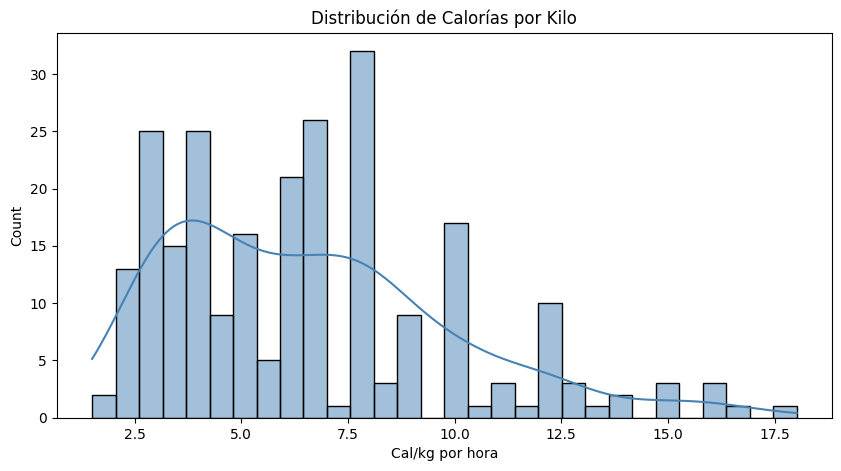

In [70]:
plt.figure(figsize=(10, 5))
sns.histplot(data['Cal/Kilo'], kde=True, bins=30, color='steelblue')
plt.title('Distribución de Calorías por Kilo')
plt.xlabel('Cal/kg por hora')
plt.show()

##### Boxplots

La distribución nos muestra que la gran mayoría de las actividades fisicas presentadas suponen un gasto entre 2.5 y 9 cal/kg por hora siendo el peak en 8 cal/kg, con muy pocos resultados sobre los 15 cal/kg porque estos resultan en actividades de alto rendimiento más pensado en atletas.

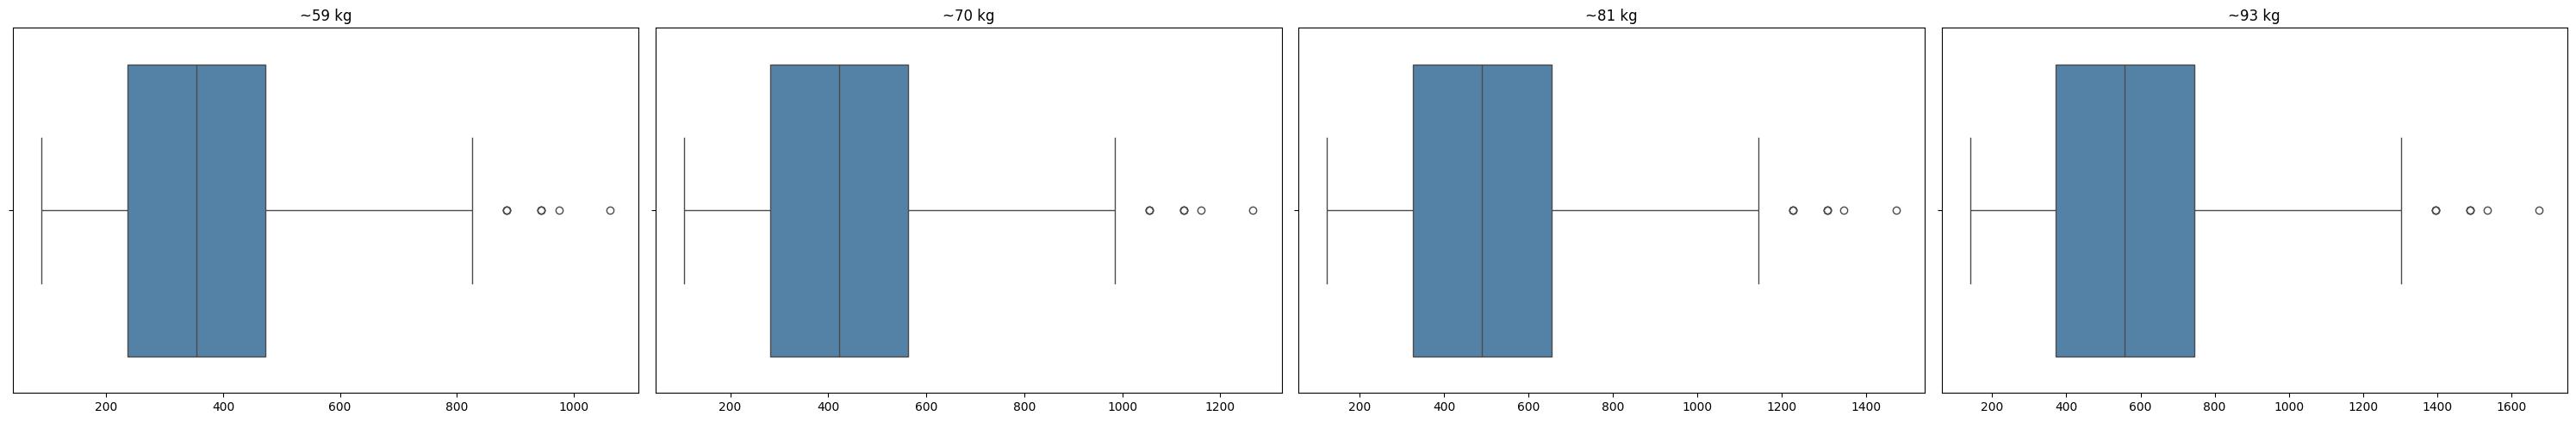

In [84]:
cols = ['~59 kg', '~70 kg', '~81 kg', '~93 kg']
fig, axes = plt.subplots(1, 4, figsize=(30, 5))
for ax, col in zip(axes, cols):
    sns.boxplot(x=data[col], ax=ax, color='steelblue')
    ax.set_title(f'{col}')
    ax.set_xlabel('')
plt.tight_layout()
plt.show()

El análisis visual de estos boxplots puede validar la relación directa que existe entre más mas corporal es un incremento en el gasto energético, siendo más calorías. Por otra parte, el hecho de que todos los rectángulos muestren un tamaño y una proporción similar a la vista se debe por el cálculo de las calorías para cada peso, el cual se deriva proporcionalmente de la columna de cal/kg. Esto provoca que, aunque los valores vayan cambiando según el grupo de peso, la dispersión y distribución se mantengan constantes.

##### Scatterplot

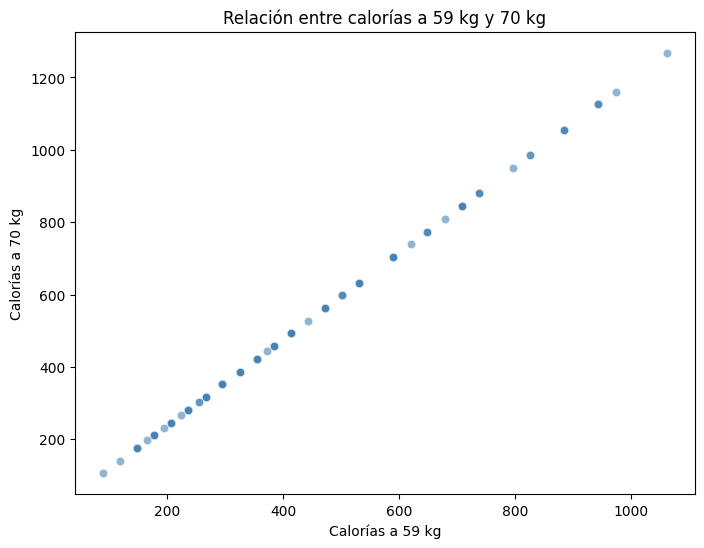

In [99]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=data, x='~59 kg', y='~70 kg', alpha=0.6, color='steelblue')
plt.title('Relación entre calorías a 59 kg y 70 kg')
plt.xlabel('Calorías a 59 kg')
plt.ylabel('Calorías a 70 kg')
plt.show()

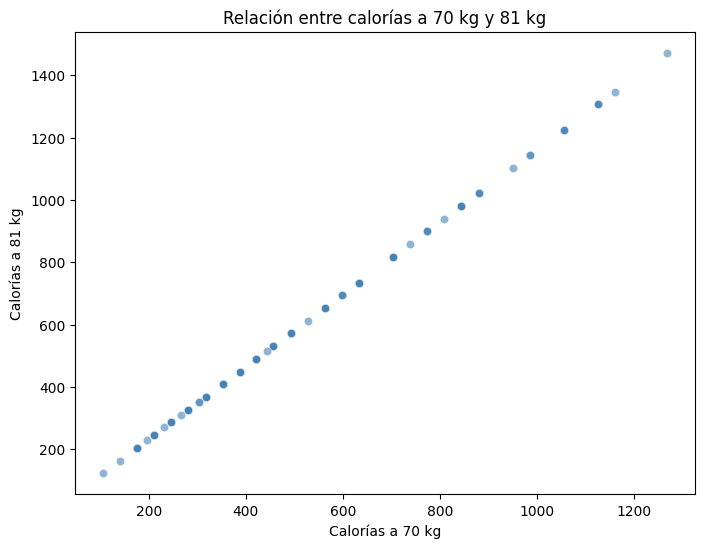

In [100]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=data, x='~70 kg', y='~81 kg', alpha=0.6, color='steelblue')
plt.title('Relación entre calorías a 70 kg y 81 kg')
plt.xlabel('Calorías a 70 kg')
plt.ylabel('Calorías a 81 kg')
plt.show()

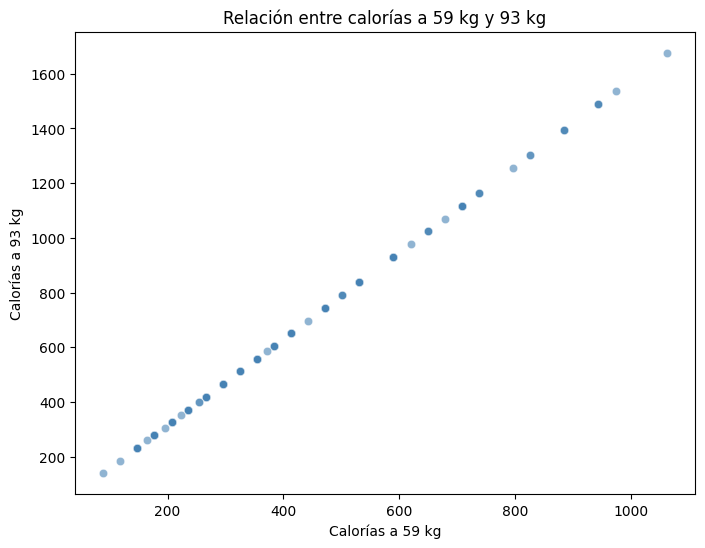

In [101]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=data, x='~59 kg', y='~93 kg', alpha=0.6, color='steelblue')
plt.title('Relación entre calorías a 59 kg y 93 kg')
plt.xlabel('Calorías a 59 kg')
plt.ylabel('Calorías a 93 kg')
plt.show()

Se realizaron ScatterPlots con el objetivo de tener visualmente la relación entre las variables de pesos:

 (1) Pesos iniciales(59kg y 70kg)

 (2) Pesos intermedios(70kg y 81kg) 

 (3) Psos en cada extremo(59kg y 93kg)

  En todos los casos anlizados, los puntos se distribuyen sobre una linea recta en pendiente positiva. Este comportamiento es consistente con lo dicho anteriormente, que el gasto calórico es proporcional al peso. Esta relacion lineal observada respalda el uso del modelo de Regresión Lineal como herramienta predictiva, modelos más complejos no aportarian una mejora notable y solo agregarían dificultad.